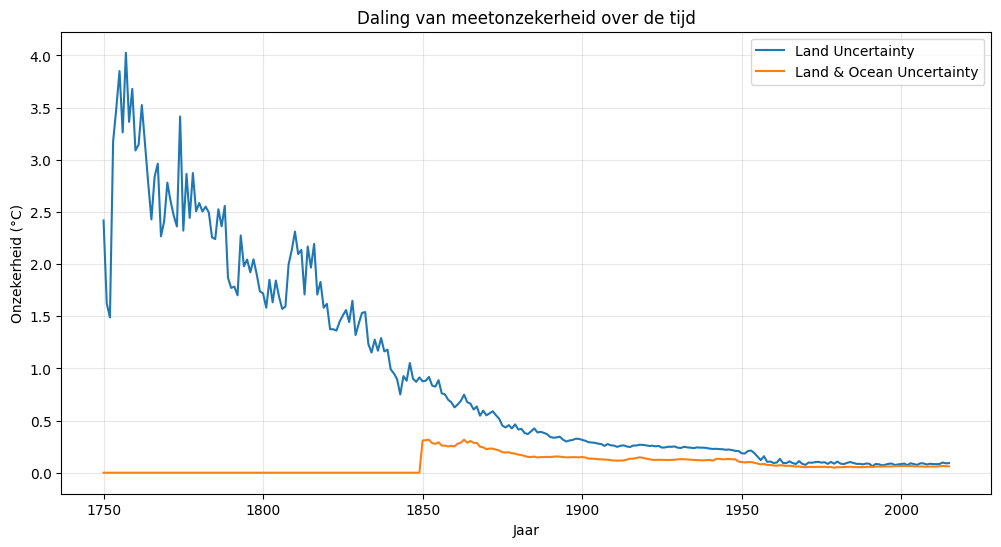

Analyse succesvol uitgevoerd!


In [5]:
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns

# Verbinding herstellen
engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

# 1. PAS HIER DE TABELNAAM AAN (bijv. 'global_temperatures' of 'GlobalTemperatures')
tabel_naam = 'global_temperatures' 

try:
    query = f"""
    SELECT dt, 
           LandAverageTemperatureUncertainty, 
           LandAndOceanAverageTemperatureUncertainty 
    FROM {tabel_naam}
    """
    df_unc = pd.read_sql(query, engine)
    
    # 2. Data verwerken
    df_unc['dt'] = pd.to_datetime(df_unc['dt'])
    df_unc['year'] = df_unc['dt'].dt.year
    
    # Groeperen per jaar voor de trend
    yearly_unc = df_unc.groupby('year')[['LandAverageTemperatureUncertainty', 'LandAndOceanAverageTemperatureUncertainty']].mean().reset_index()

    # 3. Visualisatie
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=yearly_unc, x='year', y='LandAverageTemperatureUncertainty', label='Land Uncertainty')
    sns.lineplot(data=yearly_unc, x='year', y='LandAndOceanAverageTemperatureUncertainty', label='Land & Ocean Uncertainty')

    plt.title('Daling van meetonzekerheid over de tijd')
    plt.xlabel('Jaar')
    plt.ylabel('Onzekerheid (°C)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Analyse succesvol uitgevoerd!")

except Exception as e:
    print(f" Het is nog niet gelukt. Foutmelding: {e}")
    print("Check in phpMyAdmin of de tabelnaam klopt.")

In [4]:
import pandas as pd
import sqlalchemy as sa
import os

# 1. Verbinding maken
engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

# 2. Map aanmaken als deze nog niet bestaat
if not os.path.exists('eind-rapportages'):
    os.makedirs('eind-rapportages')

try:
    # 3. Data ophalen en berekenen (Onzekerheid)
    df_unc_raw = pd.read_sql("SELECT dt, LandAverageTemperatureUncertainty FROM global_temperatures", engine)
    df_unc_raw['dt'] = pd.to_datetime(df_unc_raw['dt'])
    df_unc_raw['year'] = df_unc_raw['dt'].dt.year
    yearly_unc = df_unc_raw.groupby('year')['LandAverageTemperatureUncertainty'].mean().reset_index()
    
    # 4. Data ophalen voor Landen (Power BI kaart)
    df_country_map = pd.read_sql("SELECT Country, AverageTemperature FROM cleaned_global_temp_country", engine)
    
    # 5. EXPORTEREN
    yearly_unc.to_csv('eind-rapportages/onzekerheid_trends.csv', index=False)
    df_country_map.to_csv('eind-rapportages/landen_temperaturen.csv', index=False)
    
    print("✅ Succes! De bestanden staan in de map 'eind-rapportages'.")
    display(yearly_unc.tail(3)) # Laatste check

except Exception as e:
    print(f"❌ Er ging iets mis: {e}")

✅ Succes! De bestanden staan in de map 'eind-rapportages'.


,year,LandAverageTemperatureUncertainty
263,2013,0.097667
264,2014,0.090167
265,2015,0.092167


In [6]:
import pandas as pd
import sqlalchemy as sa

engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

try:
    # 1. Haal de stadsdata op (let op de kleine letters 'averagetemperature')
    df_city_raw = pd.read_sql("SELECT city, latitude, longitude, average_temp FROM cleaned_global_temp_major_city", engine)

    # 2. Functie om coördinaten te fixen voor Power BI
    def clean_coords(coord):
        if coord is None: return 0.0
        coord = str(coord).upper()
        if 'S' in coord or 'W' in coord:
            return -float(coord[:-1])
        return float(coord[:-1])

    df_city_raw['lat'] = df_city_raw['latitude'].apply(clean_coords)
    df_city_raw['lon'] = df_city_raw['longitude'].apply(clean_coords)

    # 3. Exporteer naar de map 'eind-rapportages'
    df_city_raw.to_csv('eind-rapportages/steden_analyse.csv', index=False)
    
    print("✅ Het missende bestand 'steden_analyse.csv' is aangemaakt!")
    display(df_city_raw.head(3))

except Exception as e:
    print(f"❌ Fout bij exporteren: {e}")

❌ Fout bij exporteren: could not convert string to float: '70.05E'


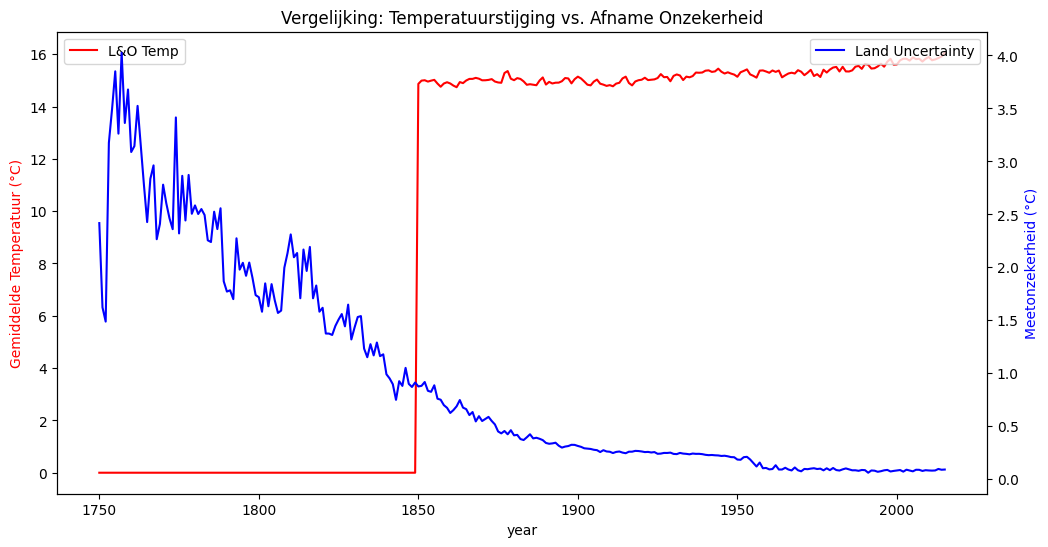

In [8]:
try:
    # Voeg LandAndOceanAverageTemperature toe aan de query
    query = f"""
    SELECT dt, 
           LandAverageTemperatureUncertainty, 
           LandAndOceanAverageTemperature 
    FROM {tabel_naam}
    """
    df_compare = pd.read_sql(query, engine)
    
    df_compare['dt'] = pd.to_datetime(df_compare['dt'])
    df_compare['year'] = df_compare['dt'].dt.year
    
    # Middelen per jaar
    yearly_compare = df_compare.groupby('year').mean().reset_index()

    # Visualisatie met twee assen (omdat temp en onzekerheid verschillende schalen hebben)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eerste as: Werkelijke Temperatuur
    sns.lineplot(data=yearly_compare, x='year', y='LandAndOceanAverageTemperature', ax=ax1, color='red', label='L&O Temp')
    ax1.set_ylabel('Gemiddelde Temperatuur (°C)', color='red')

    # Tweede as voor de Onzekerheid
    ax2 = ax1.twinx()
    sns.lineplot(data=yearly_compare, x='year', y='LandAverageTemperatureUncertainty', ax=ax2, color='blue', label='Land Uncertainty')
    ax2.set_ylabel('Meetonzekerheid (°C)', color='blue')

    plt.title('Vergelijking: Temperatuurstijging vs. Afname Onzekerheid')
    plt.show()

except Exception as e:
    print(f"Fout: {e}")

In [13]:
import pandas as pd
import sqlalchemy as sa

engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

# PROBEER DEZE NAAM EERST:
tabel_naam_globaal = 'global_temperatures' 

try:
    query = f"SELECT dt, LandAverageTemperature, LandAndOceanAverageTemperature FROM {tabel_naam_globaal}"
    df_global_temps = pd.read_sql(query, engine)

    # Verwerken
    df_global_temps['dt'] = pd.to_datetime(df_global_temps['dt'])
    df_global_temps['year'] = df_global_temps['dt'].dt.year
    yearly_global_trends = df_global_temps.groupby('year')[['LandAverageTemperature', 'LandAndOceanAverageTemperature']].mean().reset_index()

    # Exporteer
    yearly_global_trends.to_csv('eind-rapportages/globale_temperatuur_trends.csv', index=False)
    print("✅ Succes! 'globale_temperatuur_trends.csv' is aangemaakt.")
    display(yearly_global_trends.head(10))

except Exception as e:
    print(f"❌ Fout: De tabel '{tabel_naam_globaal}' is niet gevonden.")
    # Laat de gebruiker zien welke tabellen er wél zijn:
    inspector = sa.inspect(engine)
    print(f"Beschikbare tabellen in je database: {inspector.get_table_names()}")

✅ Succes! 'globale_temperatuur_trends.csv' is aangemaakt.


,year,LandAverageTemperature,LandAndOceanAverageTemperature
0,1750,7.992750,0.0
1,1751,4.652750,0.0
2,1752,2.889917,0.0
3,1753,8.388083,0.0
4,1754,8.469333,0.0
5,1755,8.355583,0.0
6,1756,8.849583,0.0
7,1757,9.022000,0.0
8,1758,6.743583,0.0
9,1759,7.985083,0.0
